# Entropy Bregman Selector on the Simplex

This notebook implements the targeted numerical experiment described in Section 6.2, `Entropy Bregman selector on the simplex`.

The goal is to illustrate the equality-constrained Bregman selector branch, which is different from the primal soft-constrained simplex-NMF experiment. We solve the entropy selector problem

$$
\begin{aligned}
&\underset{x\in\Delta_n}{\operatorname{minimize}} && \sum_{j=1}^n x_j\log x_j \\
&\operatorname{subject\ to} && Ax=b.
\end{aligned}
$$

The experiment constructs an interior simplex point $\hat{x}$, sets $b=A\hat{x}$, and runs the dual entropy Bregman--Kaczmarz update

$$
\begin{aligned}
u_{k+1}&=u_k-\eta\frac{A_i x_k-b_i}{\lVert A_i\rVert_2^2}A_i^{\top},\\
x_{k+1}&=\operatorname{softmax}(u_{k+1}).
\end{aligned}
$$

We monitor the residual $\lVert Ax_k-b\rVert_2^2$, the Bregman distance $\operatorname{KL}(\hat{x}\,\Vert\,x_k)$, and the local error-bound ratio

$$
\frac{\operatorname{KL}(\hat{x}\,\Vert\,x_k)}{\lVert Ax_k-b\rVert_2^2}.
$$

## Table of Contents

- [1. Setup and utilities](#1-setup-and-utilities)
- [2. Synthetic entropy selector instance](#2-synthetic-entropy-selector-instance)
- [3. Dual entropy Bregman-Kaczmarz update](#3-dual-entropy-bregman-kaczmarz-update)
- [4. Single-run local contraction diagnostics](#4-single-run-local-contraction-diagnostics)
- [5. Local error-bound ratio check](#5-local-error-bound-ratio-check)
- [6. Repeated randomized runs](#6-repeated-randomized-runs)
- [7. Paper-style figure export](#7-paper-style-figure-export)


**Compliance update.** This version preserves every experiment, diagnostic, printed summary, displayed figure, and PDF export from Zeyu's original notebook. The local parameter \(\delta\) is now the actual initialization ratio used in the paper. The local-neighborhood condition is checked at every row update, not only at recorded epochs. The repeated-run plot retains the median and interquartile band and additionally reports the empirical mean, which is the quantity directly connected with the expectation in Theorem 5.15.

The saved cell outputs are retained only as a visual record of the original notebook. After copying this file into the project, use **Restart Kernel and Run All** to regenerate all numerical values and figures with the corrected code.

## 1. Setup and utilities

The entropy potential on the simplex has mirror map $\operatorname{softmax}$. The Bregman distance induced by this potential is

$$
\operatorname{KL}(\hat{x}\,\Vert\,x)=\sum_{j=1}^n \hat{x}_j\log\!\left(\frac{\hat{x}_j}{x_j}\right).
$$

For the local simplex error-bound diagnostic, we use the tangent space

$$
T_\Delta=\left\{z\in\mathbb{R}^n:\mathbf{1}^{\top}z=0\right\}.
$$

and the restricted singular value

$$
\sigma_\Delta(A)=\min_{\substack{z\in T_\Delta\\ \lVert z\rVert_2=1}}\lVert Az\rVert_2.
$$

If $\alpha=\min_j\hat{x}_j$ and the iterates satisfy $\lVert x_k-\hat{x}\rVert_\infty\le\delta\alpha$, the local calculation in Section 5.7 gives the diagnostic bound

$$
\operatorname{KL}(\hat{x}\,\Vert\,x_k)\le\frac{\lVert Ax_k-b\rVert_2^2}{\theta_\delta},
\qquad
\theta_\delta=2(1-\delta)^2\alpha\,\sigma_\Delta(A)^2.
$$


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


# ============================================================
# Basic simplex and entropy utilities
# ============================================================

def softmax(u):
    """Stable softmax map from dual variables to the simplex."""
    z = np.asarray(u, dtype=float) - np.max(u)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)


def kl_xhat_to_x(x_hat, x, eps=1e-300):
    """KL(x_hat || x), with a tiny floor only to avoid log underflow."""
    p = np.maximum(np.asarray(x_hat, dtype=float), eps)
    q = np.maximum(np.asarray(x, dtype=float), eps)
    return float(np.sum(p * np.log(p / q)))


def simplex_tangent_basis(n):
    """Return an orthonormal basis for {z : 1^T z = 0}."""
    B = np.eye(n)[:, :-1] - np.eye(n)[:, [-1]]
    Q, _ = np.linalg.qr(B)
    return Q[:, : n - 1]


def restricted_singular_value(A):
    """Compute sigma_Delta(A), the smallest singular value on the simplex tangent space."""
    Q = simplex_tangent_basis(A.shape[1])
    singular_values = np.linalg.svd(A @ Q, compute_uv=False)
    return float(singular_values[-1]), singular_values


def make_close_simplex_point(x_hat, relative_inf_radius=0.25, seed=0):
    """
    Create x0 in the simplex with ||x0 - x_hat||_inf approximately
    relative_inf_radius * min_j x_hat_j.
    """
    rng = np.random.default_rng(seed)
    x_hat = np.asarray(x_hat, dtype=float)
    alpha = float(np.min(x_hat))

    v = rng.standard_normal(x_hat.size)
    v = v - np.mean(v)
    v = v / max(np.max(np.abs(v)), 1e-15)
    v = relative_inf_radius * alpha * v

    x0 = x_hat + v
    if np.min(x0) <= 0:
        raise ValueError("Initial point left the relative interior of the simplex.")

    # The perturbation has zero sum up to roundoff; renormalize for safety.
    x0 = np.maximum(x0, 1e-300)
    x0 = x0 / np.sum(x0)
    return x0


def make_entropy_selector_instance(
    m=120,
    n=60,
    target_spread=0.25,
    init_relative_radius=0.25,
    seed=7,
    min_restricted_sigma=1e-10,
    max_tries=100,
):
    """
    Construct x_hat in relint(Delta), b = A x_hat, and an initial x0 close to x_hat.

    A is regenerated until it is injective on the simplex tangent space, measured by
    sigma_Delta(A) > min_restricted_sigma. For m >= n, a random Gaussian matrix is
    full column rank with probability one, which is stronger than the tangent-space condition.
    """
    rng = np.random.default_rng(seed)

    target_logits = target_spread * rng.standard_normal(n)
    x_hat = softmax(target_logits)

    A = None
    sigma_delta = None
    singular_values = None
    for _ in range(max_tries):
        candidate = rng.standard_normal((m, n)) / np.sqrt(n)
        sigma_candidate, singular_candidate = restricted_singular_value(candidate)
        rank_augmented = np.linalg.matrix_rank(np.vstack([candidate, np.ones((1, n))]))
        if sigma_candidate > min_restricted_sigma and rank_augmented == n:
            A = candidate
            sigma_delta = sigma_candidate
            singular_values = singular_candidate
            break

    if A is None:
        raise RuntimeError("Failed to generate a tangent-injective matrix A.")

    b = A @ x_hat
    x0 = make_close_simplex_point(x_hat, relative_inf_radius=init_relative_radius, seed=seed + 1)
    u0 = np.log(x0)

    return {
        "A": A,
        "b": b,
        "x_hat": x_hat,
        "x0": x0,
        "u0": u0,
        "sigma_delta": sigma_delta,
        "tangent_singular_values": singular_values,
        "alpha": float(np.min(x_hat)),
    }


def local_error_bound_constants(A, x_hat, delta=0.5):
    """Return the local simplex error-bound constants used for diagnostics."""
    sigma_delta, singular_values = restricted_singular_value(A)
    alpha = float(np.min(x_hat))
    theta_asymptotic = 2.0 * alpha * sigma_delta**2
    theta_delta = 2.0 * (1.0 - delta) ** 2 * alpha * sigma_delta**2
    return {
        "alpha": alpha,
        "delta": float(delta),
        "sigma_delta": sigma_delta,
        "theta_asymptotic": theta_asymptotic,
        "theta_delta": theta_delta,
        "ratio_bound_asymptotic": 1.0 / theta_asymptotic,
        "ratio_bound_delta": 1.0 / theta_delta,
        "tangent_singular_values": singular_values,
    }


def print_dict(d, keys):
    for key in keys:
        value = d[key]
        if isinstance(value, str):
            print(f"{key}: {value}")
        elif isinstance(value, int):
            print(f"{key}: {value:d}")
        else:
            print(f"{key}: {value:.6e}")


## 2. Synthetic entropy selector instance

We construct $\hat{x}$ in the relative interior of the simplex and set $b=A\hat{x}$. The matrix $A$ is chosen so that it is injective on the simplex tangent space. In this synthetic test we take $m\ge n$, so a Gaussian $A$ is full column rank with probability one; this is stronger than the tangent-space condition.

The initial point $x_0$ is chosen close to $\hat{x}$, which aligns the experiment with the local error-bound calculation in Section 5.7.


In [10]:
# ============================================================
# Build a local simplex selector test instance
# ============================================================

DATA_CONFIG = {
    "m": 1000,
    "n": 200,
    "target_spread": 0.25,
    "init_relative_radius": 0.25,
    "seed": 7,
}

instance = make_entropy_selector_instance(**DATA_CONFIG)
A = instance["A"]
b = instance["b"]
x_hat = instance["x_hat"]
x0 = instance["x0"]
u0 = instance["u0"]

# Match the paper exactly: delta is the actual initialization ratio.
initial_linf_over_alpha = (
    np.max(np.abs(x0 - x_hat)) / max(float(np.min(x_hat)), 1e-300)
)
LOCAL_EB_CONFIG = {
    "delta": float(initial_linf_over_alpha),
}

constants = local_error_bound_constants(A, x_hat, delta=LOCAL_EB_CONFIG["delta"])

print("Instance summary")
print("A shape:", A.shape)
print("simplex sum x_hat:", np.sum(x_hat))
print("simplex sum x0:", np.sum(x0))
print("min_j x_hat_j:", constants["alpha"])
print("sigma_Delta(A):", constants["sigma_delta"])
print("delta used in the local bound:", constants["delta"])
print("theta_delta:", constants["theta_delta"])
print("1 / theta_delta:", constants["ratio_bound_delta"])
print("||x0 - x_hat||_inf / alpha:", np.max(np.abs(x0 - x_hat)) / constants["alpha"])
print("||A x_hat - b||_2:", np.linalg.norm(A @ x_hat - b))


Instance summary
A shape: (1000, 200)
simplex sum x_hat: 1.0
simplex sum x0: 1.0
min_j x_hat_j: 0.00268998901849137
sigma_Delta(A): 1.2780136957256225
theta_delta: 0.002196805095538363
1 / theta_delta: 455.206518789931
||x0 - x_hat||_inf / alpha: 0.25
||A x_hat - b||_2: 0.0


## 3. Dual entropy Bregman-Kaczmarz update

The update is performed in the dual variable $u$. The primal iterate is always reconstructed by $\operatorname{softmax}(u)$, so every iterate remains in the simplex without an explicit Euclidean projection.

Rows are sampled with probabilities proportional to $\lVert A_i\rVert_2^2$, matching the randomized row-action scaling used in the theory.


In [11]:
# ============================================================
# Dual entropy Bregman-Kaczmarz algorithm
# ============================================================

def entropy_bregman_kaczmarz(
    A,
    b,
    x_hat,
    u0,
    n_iters,
    eta=1.0,
    seed=0,
    record_every=None,
    local_delta=None,
    local_tolerance=1e-12,
):
    rng = np.random.default_rng(seed)
    m, n = A.shape

    row_norm_sq = np.sum(A * A, axis=1)
    if np.any(row_norm_sq <= 0):
        raise ValueError("All rows of A must be nonzero.")
    probs = row_norm_sq / np.sum(row_norm_sq)

    if record_every is None:
        record_every = m

    u = np.array(u0, dtype=float, copy=True)
    x = softmax(u)
    alpha = max(float(np.min(x_hat)), 1e-300)
    t0 = perf_counter()

    hist = {
        "iter": [],
        "epoch": [],
        "time": [],
        "residual_norm": [],
        "residual_sq": [],
        "kl": [],
        "l2_error": [],
        "linf_over_alpha": [],
        "eb_ratio": [],
        "theta_empirical": [],
    }

    def record(k):
        residual = A @ x - b
        residual_sq = float(np.dot(residual, residual))
        kl_value = kl_xhat_to_x(x_hat, x)
        l2_error = float(np.linalg.norm(x - x_hat))
        linf_over_alpha = float(np.max(np.abs(x - x_hat)) / alpha)

        hist["iter"].append(k)
        hist["epoch"].append(k / m)
        hist["time"].append(perf_counter() - t0)
        hist["residual_norm"].append(float(np.sqrt(residual_sq)))
        hist["residual_sq"].append(residual_sq)
        hist["kl"].append(kl_value)
        hist["l2_error"].append(l2_error)
        hist["linf_over_alpha"].append(linf_over_alpha)
        hist["eb_ratio"].append(kl_value / residual_sq if residual_sq > 0 else np.nan)
        hist["theta_empirical"].append(residual_sq / kl_value if kl_value > 0 else np.nan)

    initial_linf_over_alpha = float(np.max(np.abs(x - x_hat)) / alpha)
    max_linf_over_alpha_all = initial_linf_over_alpha
    all_inside_local_region = (
        True
        if local_delta is None
        else initial_linf_over_alpha <= local_delta + local_tolerance
    )

    record(0)

    for k in range(1, n_iters + 1):
        i = rng.choice(m, p=probs)
        residual_i = float(A[i, :] @ x - b[i])
        u = u - eta * (residual_i / row_norm_sq[i]) * A[i, :]
        x = softmax(u)

        # Check the local neighborhood at every row update.
        linf_over_alpha_current = float(np.max(np.abs(x - x_hat)) / alpha)
        max_linf_over_alpha_all = max(
            max_linf_over_alpha_all, linf_over_alpha_current
        )
        if local_delta is not None:
            all_inside_local_region = (
                all_inside_local_region
                and linf_over_alpha_current <= local_delta + local_tolerance
            )

        if k % record_every == 0 or k == n_iters:
            record(k)

    for key in hist:
        hist[key] = np.array(hist[key])

    hist["max_linf_over_alpha_all"] = float(max_linf_over_alpha_all)
    hist["all_inside_local_region"] = bool(all_inside_local_region)

    return x, u, hist


def fit_log_linear_rate(epoch, values, start_fraction=0.1, floor=1e-300):
    """Fit log(values) approximately as intercept + slope * epoch."""
    epoch = np.asarray(epoch, dtype=float)
    values = np.maximum(np.asarray(values, dtype=float), floor)
    start = int(np.floor(start_fraction * len(values)))
    idx = np.arange(len(values)) >= start
    idx &= np.isfinite(values)
    slope, intercept = np.polyfit(epoch[idx], np.log(values[idx]), 1)
    return slope, intercept, np.exp(slope)


## 4. Single-run local contraction diagnostics

The first diagnostic run monitors the residual and the KL distance. A straight line on the semilog plot indicates linear decrease with respect to epochs.


In [12]:
# ============================================================
# Run one local entropy Bregman-Kaczmarz trajectory
# ============================================================

RUN_CONFIG = {
    "eta": 1.0,
    "n_epochs": 200,
    "record_every": max(1, A.shape[0] // 5),
    "seed": 20,
}

n_iters = RUN_CONFIG["n_epochs"] * A.shape[0]

x_last, u_last, hist = entropy_bregman_kaczmarz(
    A,
    b,
    x_hat,
    u0,
    n_iters=n_iters,
    eta=RUN_CONFIG["eta"],
    seed=RUN_CONFIG["seed"],
    record_every=RUN_CONFIG["record_every"],
    local_delta=constants["delta"],
)

kl_slope, kl_intercept, kl_factor_per_epoch = fit_log_linear_rate(hist["epoch"], hist["kl"])
res_slope, res_intercept, res_factor_per_epoch = fit_log_linear_rate(hist["epoch"], hist["residual_sq"])

print("Run summary")
print("eta:", RUN_CONFIG["eta"])
print("row updates:", n_iters)
print("epochs:", RUN_CONFIG["n_epochs"])
print("initial KL:", hist["kl"][0])
print("final KL:", hist["kl"][-1])
print("initial residual squared:", hist["residual_sq"][0])
print("final residual squared:", hist["residual_sq"][-1])
print("fitted KL factor per epoch:", kl_factor_per_epoch)
print("fitted residual-squared factor per epoch:", res_factor_per_epoch)
print("final ||x - x_hat||_inf / alpha:", hist["linf_over_alpha"][-1])
print("maximum ||x_k - x_hat||_inf / alpha over all row updates:", hist["max_linf_over_alpha_all"])
print("all row iterates inside the local region:", hist["all_inside_local_region"])


Run summary
eta: 1.0
row updates: 200000
epochs: 200
initial KL: 0.0010424648735802451
final KL: 5.091178910599114e-06
initial residual squared: 4.9695098760734106e-05
final residual squared: 9.978606737789854e-08
fitted KL factor per epoch: 0.976240200972972
fitted residual-squared factor per epoch: 0.9729602472169516
final ||x - x_hat||_inf / alpha: 0.016144976291197467


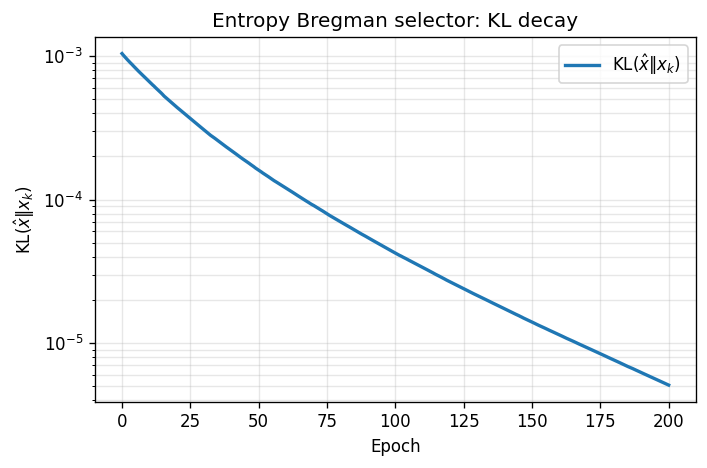

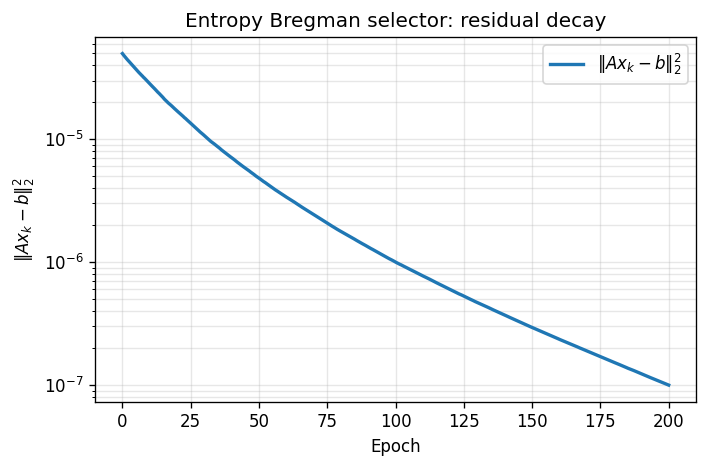

In [13]:
# ============================================================
# Plot KL distance and residual decay
# ============================================================

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(hist["epoch"], hist["kl"], linewidth=2, label=r"$\mathrm{KL}(\hat{x}\Vert x_k)$")
# ax.semilogy(
#     hist["epoch"],
#     np.exp(kl_intercept + kl_slope * hist["epoch"]),
#     linestyle="--",
#     color="black",
#     alpha=0.75,
#     label="log-linear fit",
# )
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\mathrm{KL}(\hat{x}\Vert x_k)$")
ax.set_title("Entropy Bregman selector: KL decay")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(hist["epoch"], hist["residual_sq"], linewidth=2, label=r"$\|Ax_k-b\|_2^2$")
# ax.semilogy(
#     hist["epoch"],
#     np.exp(res_intercept + res_slope * hist["epoch"]),
#     linestyle="--",
#     color="black",
#     alpha=0.75,
#     label="log-linear fit",
# )
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\|Ax_k-b\|_2^2$")
ax.set_title("Entropy Bregman selector: residual decay")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Local error-bound ratio check

The local theory predicts that, once the iterates remain in the neighborhood

$$
\lVert x_k-\hat{x}\rVert_\infty\le\delta\min_j\hat{x}_j,
$$

the ratio $\operatorname{KL}(\hat{x}\,\Vert\,x_k)/\lVert Ax_k-b\rVert_2^2$ should stay below $1/\theta_\delta$. The plot below checks this numerically.


Fraction of recorded iterates inside local region: 1.0
max KL/residual_sq over recorded iterates: 51.020939539769365
1/theta_delta: 455.206518789931
1/theta_asymptotic: 113.80162969748275
min empirical theta = min residual_sq/KL: 0.019599795868528228
theta_delta: 0.002196805095538363


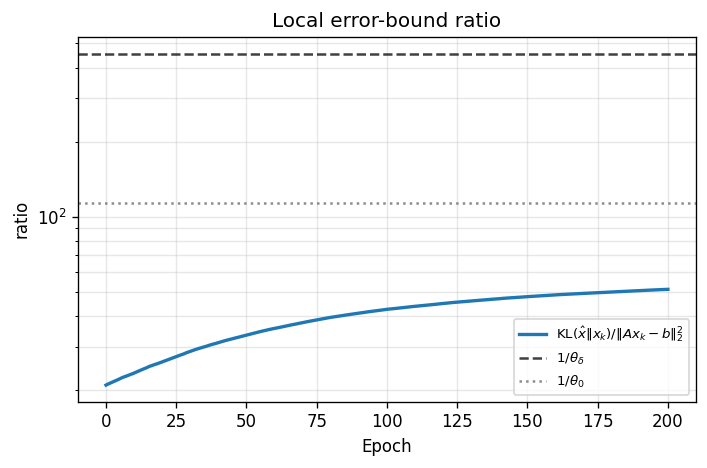

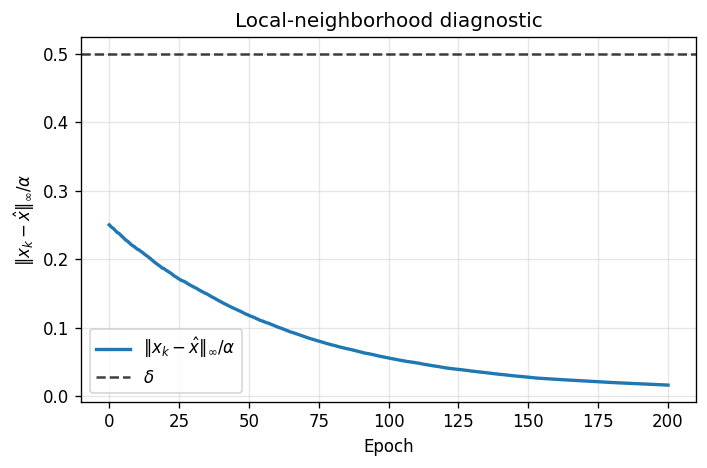

In [ ]:
# ============================================================
# Check the local error-bound ratio
# ============================================================

ratio_bound_delta = constants["ratio_bound_delta"]
ratio_bound_asymptotic = constants["ratio_bound_asymptotic"]
delta = constants["delta"]

inside_local_region = hist["linf_over_alpha"] <= delta
print("Fraction of recorded iterates inside local region:", np.mean(inside_local_region))
print("Maximum neighborhood ratio over all row updates:", hist["max_linf_over_alpha_all"])
print("All row iterates inside local region:", hist["all_inside_local_region"])
print("max KL/residual_sq over recorded iterates:", np.nanmax(hist["eb_ratio"]))
print("1/theta_delta:", ratio_bound_delta)
print("1/theta_asymptotic:", ratio_bound_asymptotic)
print("min empirical theta = min residual_sq/KL:", np.nanmin(hist["theta_empirical"]))
print("theta_delta:", constants["theta_delta"])

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(hist["epoch"], hist["eb_ratio"], linewidth=2, label=r"$\mathrm{KL}(\hat{x}\Vert x_k)/\|Ax_k-b\|_2^2$")
ax.axhline(ratio_bound_delta, linestyle="--", color="black", alpha=0.75, label=r"$1/\theta_\delta$")
ax.axhline(ratio_bound_asymptotic, linestyle=":", color="gray", alpha=0.9, label=r"$1/\theta_0$")
ax.set_xlabel("Epoch")
ax.set_ylabel("ratio")
# ax.set_title("Local error-bound ratio")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.plot(hist["epoch"], hist["linf_over_alpha"], linewidth=2, label=r"$\|x_k-\hat{x}\|_\infty/\alpha$")
ax.axhline(delta, linestyle="--", color="black", alpha=0.75, label=r"$\delta$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\|x_k-\hat{x}\|_\infty/\alpha$")
# ax.set_title("Local-neighborhood diagnostic")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Repeated randomized runs

The theorem is stated in expectation. This repeated-run diagnostic keeps the same instance and initial point and changes only the row-sampling seed. We report the empirical mean KL trajectory, which directly approximates the expectation, together with the original median and interquartile band as a stability diagnostic.


Repeated-run summary
repeats: 12
median final KL: 5.202452774007918e-06
median final residual squared: 1.0209593290689058e-07


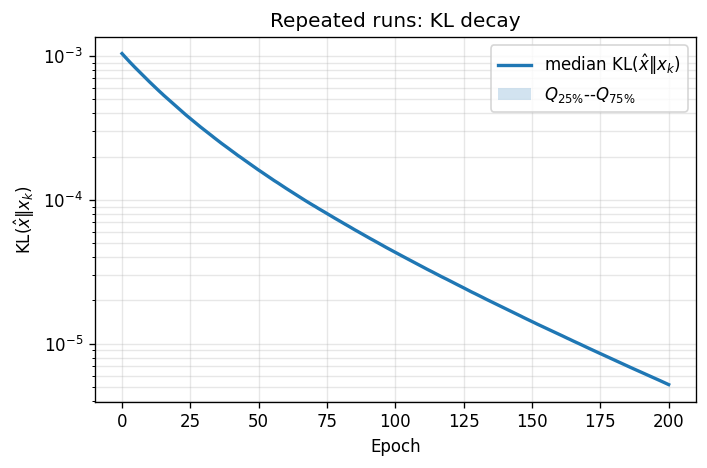

In [15]:
# ============================================================
# Repeated randomized runs
# ============================================================

REPEAT_CONFIG = {
    "n_repeats": 12,
    "eta": RUN_CONFIG["eta"],
    "n_epochs": RUN_CONFIG["n_epochs"],
    "record_every": RUN_CONFIG["record_every"],
    "seed0": 200,
}

repeat_histories = []

for rep in range(REPEAT_CONFIG["n_repeats"]):
    _, _, rep_hist = entropy_bregman_kaczmarz(
        A,
        b,
        x_hat,
        u0,
        n_iters=REPEAT_CONFIG["n_epochs"] * A.shape[0],
        eta=REPEAT_CONFIG["eta"],
        seed=REPEAT_CONFIG["seed0"] + rep,
        record_every=REPEAT_CONFIG["record_every"],
        local_delta=constants["delta"],
    )
    repeat_histories.append(rep_hist)

repeat_epoch = repeat_histories[0]["epoch"]
repeat_kl = np.vstack([h["kl"] for h in repeat_histories])
repeat_residual_sq = np.vstack([h["residual_sq"] for h in repeat_histories])

kl_mean = np.mean(repeat_kl, axis=0)
kl_median = np.median(repeat_kl, axis=0)
kl_q25 = np.quantile(repeat_kl, 0.25, axis=0)
kl_q75 = np.quantile(repeat_kl, 0.75, axis=0)

res_median = np.median(repeat_residual_sq, axis=0)
res_q25 = np.quantile(repeat_residual_sq, 0.25, axis=0)
res_q75 = np.quantile(repeat_residual_sq, 0.75, axis=0)

print("Repeated-run summary")
print("repeats:", REPEAT_CONFIG["n_repeats"])
print("mean final KL:", kl_mean[-1])
print("median final KL:", kl_median[-1])
print("median final residual squared:", res_median[-1])
print("all repeated runs stayed inside the local region:", all(h["all_inside_local_region"] for h in repeat_histories))
print("maximum neighborhood ratio over all repeated runs:", max(h["max_linf_over_alpha_all"] for h in repeat_histories))

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(repeat_epoch, kl_mean, linewidth=2, linestyle="--", label=r"mean $\mathrm{KL}(\hat{x}\Vert x_k)$")
ax.semilogy(repeat_epoch, kl_median, linewidth=2, label=r"median $\mathrm{KL}(\hat{x}\Vert x_k)$")
ax.fill_between(repeat_epoch, np.maximum(kl_q25, 1e-300), np.maximum(kl_q75, 1e-300), alpha=0.2, label=r"$Q_{25\%}$--$Q_{75\%}$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\mathrm{KL}(\hat{x}\Vert x_k)$")
ax.set_title("Repeated runs: KL decay")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 7. Paper-style figure export

Run Sections 2--6 first, then execute this cell to save PDF figures.


Saved: figures_bregman_selector/fig_bregman_selector_kl_decay.pdf


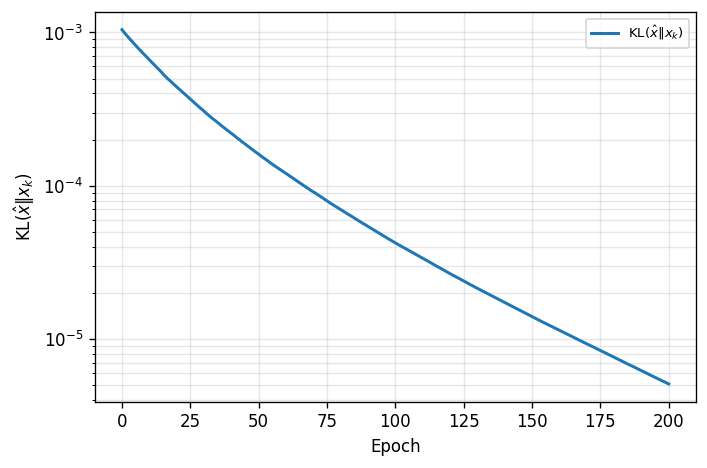

Saved: figures_bregman_selector/fig_bregman_selector_residual_decay.pdf


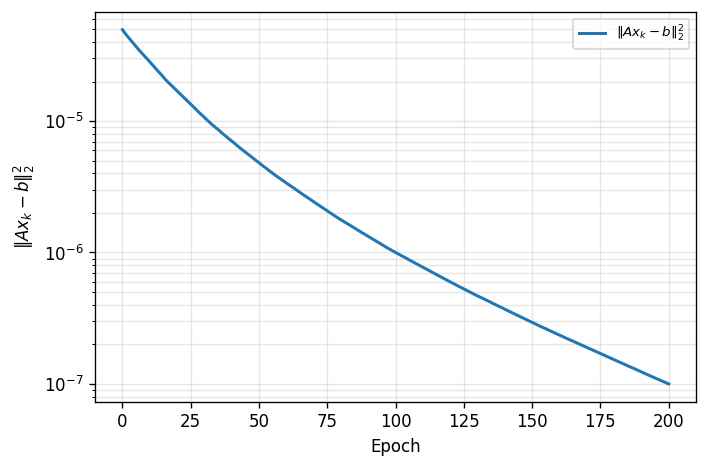

Saved: figures_bregman_selector/fig_bregman_selector_error_bound_ratio.pdf


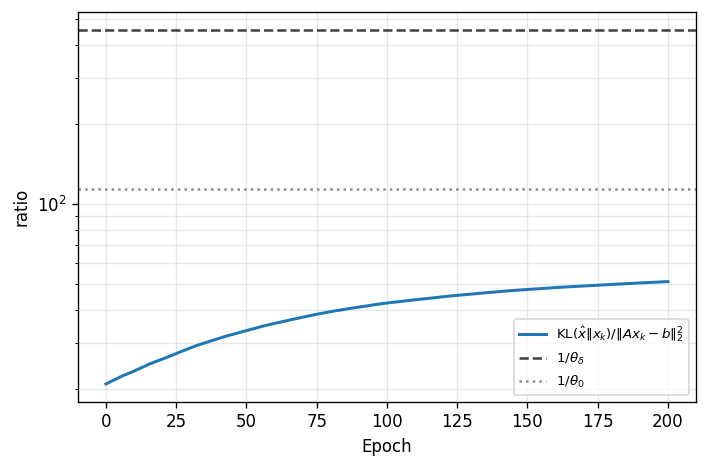

Saved: figures_bregman_selector/fig_bregman_selector_repeated_kl.pdf


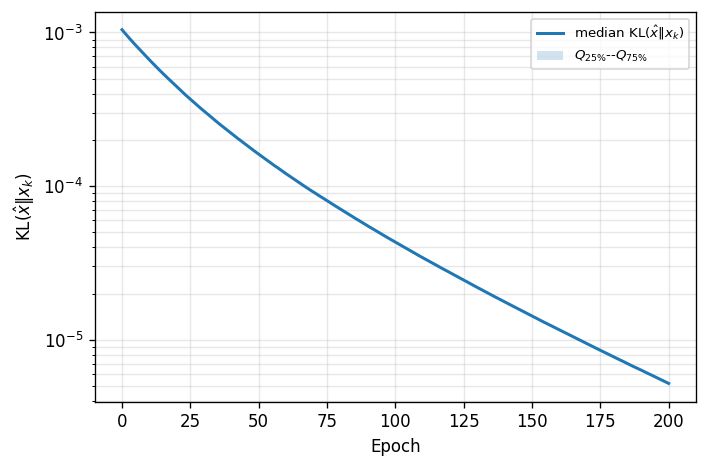

In [16]:
# ============================================================
# Save publication-style PDF figures
# ============================================================

FIG_DIR = Path("figures_bregman_selector")
FIG_DIR.mkdir(exist_ok=True)


def save_pdf(fig, filename, dpi=600):
    path = FIG_DIR / filename
    fig.savefig(path, format="pdf", dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    print(f"Saved: {path}")


# Figure 1: single-run KL decay
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(hist["epoch"], hist["kl"], linewidth=1.8, label=r"$\mathrm{KL}(\hat{x}\Vert x_k)$")
# ax.semilogy(hist["epoch"], np.exp(kl_intercept + kl_slope * hist["epoch"]), linestyle="--", color="black", alpha=0.75, label="log-linear fit")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\mathrm{KL}(\hat{x}\Vert x_k)$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
save_pdf(fig, "fig_bregman_selector_kl_decay.pdf")
plt.show()


# Figure 2: single-run residual decay
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(hist["epoch"], hist["residual_sq"], linewidth=1.8, label=r"$\|Ax_k-b\|_2^2$")
# ax.semilogy(hist["epoch"], np.exp(res_intercept + res_slope * hist["epoch"]), linestyle="--", color="black", alpha=0.75, label="log-linear fit")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\|Ax_k-b\|_2^2$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
save_pdf(fig, "fig_bregman_selector_residual_decay.pdf")
plt.show()


# Figure 3: local error-bound ratio
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(hist["epoch"], hist["eb_ratio"], linewidth=1.8, label=r"$\mathrm{KL}(\hat{x}\Vert x_k)/\|Ax_k-b\|_2^2$")
ax.axhline(ratio_bound_delta, linestyle="--", color="black", alpha=0.75, label=r"$1/\theta_\delta$")
ax.axhline(ratio_bound_asymptotic, linestyle=":", color="gray", alpha=0.9, label=r"$1/\theta_0$")
ax.set_xlabel("Epoch")
ax.set_ylabel("ratio")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
save_pdf(fig, "fig_bregman_selector_error_bound_ratio.pdf")
plt.show()


# Figure 4: repeated-run KL median and IQR
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(repeat_epoch, kl_mean, linewidth=1.8, linestyle="--", label=r"mean $\mathrm{KL}(\hat{x}\Vert x_k)$")
ax.semilogy(repeat_epoch, kl_median, linewidth=1.8, label=r"median $\mathrm{KL}(\hat{x}\Vert x_k)$")
ax.fill_between(repeat_epoch, np.maximum(kl_q25, 1e-300), np.maximum(kl_q75, 1e-300), alpha=0.2, label=r"$Q_{25\%}$--$Q_{75\%}$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\mathrm{KL}(\hat{x}\Vert x_k)$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
save_pdf(fig, "fig_bregman_selector_repeated_kl.pdf")
plt.show()
